# Análisis Exploratorio de Datos (EDA)

**Dataset:** [Bank Account Fraud Dataset Suite (NeurIPS 2022)](https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022)  
**Problema:** Detección de fraude en solicitudes de apertura de cuentas bancarias (clasificación binaria).  
**Asignatura:** Aprendizaje Avanzado


### Objetivo del EDA

Este notebook realiza el análisis exploratorio completo previo al modelado. En su desarollo se va a tratar de:

1. **Comprender la estructura del dataset**: tipos de variables, dimensiones y primeras observaciones.
2. **Detectar problemas en los datos**: valores ausentes, outliers y desbalanceo de clases.
3. **Analizar el poder discriminativo de las variables**: distribuciones por clase, correlaciones e importancia SHAP.
4. **Identificar sesgos potenciales** en variables sensibles relevantes para el análisis de *fairness*.
5. **Preparar el dataset para el modelado**: codificación de variables categóricas y exportación de ficheros procesados.

El análisis sigue el esquema metodológico del enunciado: entender los datos antes de modelar y justificar cada decisión con evidencia empírica.


## 1. Importación de Librerías

Se cargan las librerías necesarias para todo el análisis:


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import catboost as cb
import shap
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns



## 2. Carga del Dataset

Se carga el fichero `Base.csv`, que corresponde al conjunto de datos principal del *Bank Account Fraud Dataset Suite* (NeurIPS 2022). Este dataset contiene solicitudes de apertura de cuentas bancarias, cada una etiquetada como fraudulenta (`fraud_bool = 1`) o legítima (`fraud_bool = 0`).

In [2]:
# Cargar datos
df = pd.read_csv('Base.csv')


## 3. Inspección Inicial del Dataset

### 3.1 Dimensiones

Se muestra el número total de instancias (filas) y variables (columnas). Esta información es fundamental para valorar la envergadura del dataset y detectar si el tamaño es suficiente para el entrenamiento de modelos robustos. En este caso se cuenta con un dataset con un alto número de instancias y con moderadamente alto número de variables, lo cual tiene una envergadura enorme e iremos analizando a lo largo del trabajo como repercute en la predicción de casos.

In [3]:
# Dimensiones
print(f"Shape: {df.shape}")

Shape: (1000000, 32)


### 3.2 Tipos de Datos

Se inspeccionan los tipos de dato asignados automáticamente por pandas a cada columna:
- **`int64` / `float64`**: variables numéricas (continuas o discretas).
- **`object`**: variables de texto, normalmente categóricas.

Esto es útil para saber si se cuenta con variables categóricas que deberán ser codificadas. Se puede comprobar que efectivamente si las hay.

In [4]:
# Tipos de datos
print(df.dtypes)

fraud_bool                            int64
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                         object
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                    object
credit_risk_score                     int64
email_is_free                         int64
housing_status                       object
phone_home_valid                      int64
phone_mobile_valid                    int64
bank_months_count                     int64
has_other_cards                 

### 3.3 Valores Ausentes

Se comprueba cuántos valores nulos (`NaN`) contiene cada columna. La presencia de valores faltantes puede:
- Indicar campos opcionales en el formulario de solicitud.
- Requerir imputación o eliminación antes del modelado.
- Ser informativa por sí misma (la ausencia de un dato puede correlacionar con el fraude).

En este caso no contamos con ningún valor nulo, con lo cual no se van a tratar.

In [5]:
# Valores faltantes
print(df.isnull().sum())

fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                              0
session_leng

### 3.4 Primeras Filas

Se visualizan las primeras filas del dataset para entender el contenido real de cada variable y detectar posibles inconsistencias o formatos inesperados.

In [6]:
# Primeras filas
print(df.head().to_string(
    index=True,
    justify='center',
    max_colwidth=20
))

   fraud_bool  income  name_email_similarity  prev_address_months_count  current_address_months_count  customer_age  days_since_request  intended_balcon_amount payment_type  zip_count_4w   velocity_6h  velocity_24h  velocity_4w  bank_branch_count_8w  date_of_birth_distinct_emails_4w employment_status  credit_risk_score  email_is_free housing_status  phone_home_valid  phone_mobile_valid  bank_months_count  has_other_cards  proposed_credit_limit  foreign_request   source   session_length_in_minutes device_os  keep_alive_session  device_distinct_emails_8w  device_fraud_count  month
0       0        0.3        0.986506                  -1                         25                         40            0.006735           102.453711              AA           1059      13096.035018   7850.955007  6742.080561           5                     5                               CB                163               1             BC                0                  1                  9               


## 4. Separación de la Variable Objetivo y las Features

Se separa la variable objetivo (`fraud_bool`) del resto de variables predictoras.

- **`y`**: vector binario de etiquetas (0 = legítima, 1 = fraude).
- **`X`**: matriz de features con todas las variables independientes.

Esta separación es el primer paso estándar en cualquier pipeline de ML y permite operar sobre features y target de forma independiente durante el preprocesamiento y el entrenamiento.

In [7]:
# Separar target de features
target = 'fraud_bool'
X = df.drop(columns=[target])
y = df[target]

Se almacenan ambos df para el almacenamiento seguro y el uso de ellos en archivos complementarios a este principal EDA.

In [8]:
X.to_csv("base-sin-target.csv", index=False)
y.to_csv("base-solo-target.csv", index=False)


## 5. Análisis del Desbalanceo de Clases

El fraude es un fenómeno raro por definición: la inmensa mayoría de solicitudes bancarias son legítimas. Esto genera un **desbalanceo de clases severo**, uno de los problemas centrales del proyecto.

**Implicaciones metodológicas:**
- La métrica *accuracy* es engañosa: un modelo que prediga siempre "no fraude" obtendría ~98% de exactitud sin detectar ningún caso real.
- Se deben usar métricas apropiadas: **F1-score** (clase positiva), **AUC-ROC** y **Average Precision**.
- No se aplicarán técnicas de balanceo para que el problema sea lo más real posible.

La función siguiente visualiza la distribución de clases y cuantifica el ratio de desbalanceo, el cual como se ha comentado es grandísimo.

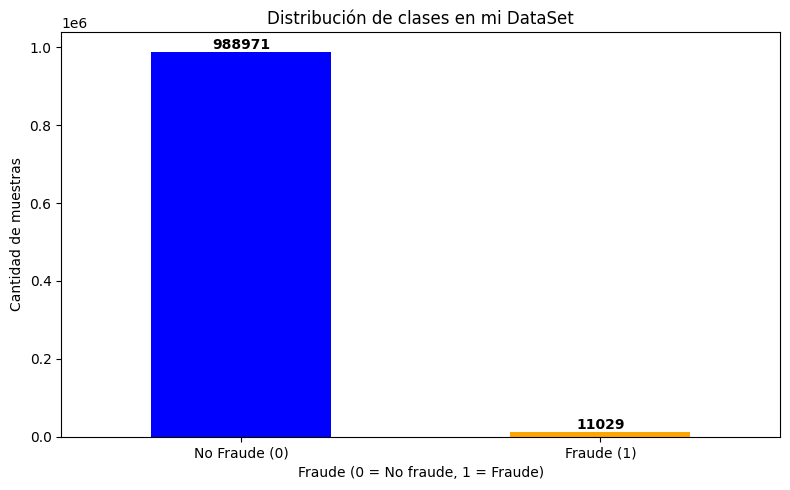

In [9]:
def imbalance_representatividad(y_series):   
    
    # Visualización
    fig, ax = plt.subplots(figsize=(8, 5))
    y_series.value_counts().plot(kind='bar', ax=ax, color=['blue', 'orange'])
    ax.set_title('Distribución de clases en mi DataSet')
    ax.set_xlabel('Fraude (0 = No fraude, 1 = Fraude)')
    ax.set_ylabel('Cantidad de muestras')
    ax.set_xticklabels(['No Fraude (0)', 'Fraude (1)'], rotation=0)
    
    # Añadir valores en las barras
    for i, v in enumerate(y_series.value_counts().values):
        ax.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('imbalance_representatividad.png')  # Guardar la figura
    plt.show()
    plt.close()

# Llamar a la función correctamente
imbalance_representatividad(y)


## 6. Identificación de Variables Categóricas

Como se ha comentado, este dataset cuenta con varias variables categóricas (`object`). Estas variables no pueden ser procesadas directamente por los algoritmos de ML y requieren codificación numérica.

Las variables categóricas presentes en el dataset son:
- **`payment_type`**: método de pago preferido por el solicitante.
- **`employment_status`**: situación laboral (empleado, autónomo, desempleado, etc.).
- **`housing_status`**: situación de vivienda (propietario, arrendatario, etc.).
- **`source`**: canal por el que llegó la solicitud (web, app móvil, etc.).
- **`device_os`**: sistema operativo del dispositivo usado en la solicitud.


In [10]:
df = pd.read_csv("base-sin-target.csv")
# Identificar columnas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Columnas categóricas:", categorical_cols)

Columnas categóricas: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']



## 7. Carga del Dataset con Variables Categóricas Codificadas

Se carga el dataset resultante del notebook `tratar_columnas_categoricas.ipynb`, que aplica **One-Hot Encoding (OHE)** a las cinco variables categóricas identificadas anteriormente.

El OHE crea una columna binaria (0/1) por cada categoría posible, eliminando una de ellas como referencia (`drop_first=True`) para evitar la trampa de las variables ficticias (multicolinealidad perfecta).

A continuación se verifica que las dimensiones son las esperadas y se muestran las nuevas columnas generadas.

In [11]:
df = pd.read_csv("base-categoricas-tratado.csv")

In [12]:
# Dimensiones
print(f"{df.shape[0]}, {df.shape[1]+1} (incluyendo target)")

1000000, 48 (incluyendo target)


In [13]:
# One-Hot columns
onehot_cols = [col for col in df.columns if any(
    col.startswith(prefix) for prefix in ['payment_type_', 'source_', 'device_os_','employment_status', 'housing_status']
)]

print(df[onehot_cols].head().to_string(index=True, max_colwidth=10))

   payment_type_AB  payment_type_AC  payment_type_AD  payment_type_AE  source_TELEAPP  device_os_macintosh  device_os_other  device_os_windows  device_os_x11  employment_status_CB  employment_status_CC  employment_status_CD  employment_status_CE  employment_status_CF  employment_status_CG  housing_status_BB  housing_status_BC  housing_status_BD  housing_status_BE  housing_status_BF  housing_status_BG
0          0                0                0                0                0               0                    0                0                  0              1                     0                     0                     0                     0                     0                     0                  1                  0                  0                  0                  0        
1          0                0                1                0                0               0                    1                0                  0              0                     0  


## 8. Detección de Outliers

Se detectan valores extremos en las variables numéricas mediante el **método IQR (Rango Intercuartílico)**:

$$\text{outlier si } x < Q_1 - 1.5 \cdot IQR \quad \text{o} \quad x > Q_3 + 1.5 \cdot IQR$$

Solo se reportan las variables con **más del 1% de outliers**, ya que un porcentaje muy bajo puede deberse a variabilidad natural.

**Interpretación en el contexto del fraude:**  
Los outliers en variables como `velocity_6h` (número de solicitudes en las últimas 6 horas) o `intended_balcon_amount` (importe solicitado) pueden ser señales reales de comportamiento fraudulento, **no errores**. Por ello, se reportan pero no se eliminan automáticamente. 

Concretar que aún sabiendo que para este problema no es recomendable tratar los outliers, se trataron en el achivo `tratar_outliers`, el cual fue probado en el apartado de los modelos y como se estimaba, los resultados fueron malos.

La función auxiliar `get_numeric_cols` excluye explícitamente las columnas one-hot y el target, ya que son binarias y no tiene sentido detectar outliers en ellas.

In [14]:
def detectar_outliers(df, columnas):
    resultados = {}
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        pct = outliers / len(df) * 100
        if pct > 1:
            resultados[col] = round(pct, 2)

    resultado_series = pd.Series(resultados).sort_values()

    fig, ax = plt.subplots(figsize=(8, len(resultado_series) * 0.5 + 1))
    bars = ax.barh(resultado_series.index, resultado_series.values, color="crimson")
    for bar, val in zip(bars, resultado_series.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val}%", va="center")
    ax.set_xlabel("% outliers")
    ax.set_title("Variables con más del 1% de outliers (IQR x1.5)")
    ax.set_xlim(0, resultado_series.max() + 5)
    plt.tight_layout()
    plt.savefig("outliers_iqr.png", dpi=300)
    plt.show()

['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


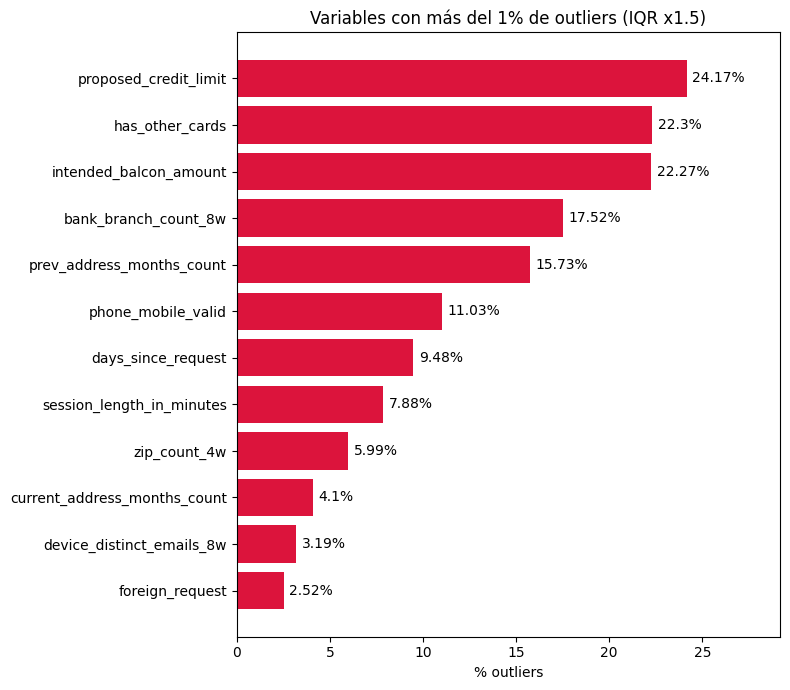

In [15]:
def get_numeric_cols(df):
    """Devuelve todas las columnas numéricas excepto las categóricas tratadas"""
    
    # Excluir one-hot (payment_type_, source_, device_os_)
    excluir = [col for col in df.columns if any(
        col.startswith(p) for p in ['payment_type_', 'source_', 'device_os_', 'employment_status', 'housing_status']
    )]
    
    # Excluir target
    if 'fraud_bool' in df.columns:
        excluir.append('fraud_bool')
    
    # Columnas numéricas que no están en excluir
    numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    resultado = [col for col in numericas if col not in excluir]
    
    return resultado

# Usar
columnas_numericas = get_numeric_cols(df)
print(columnas_numericas)

detectar_outliers(df, columnas_numericas)


## 9. Importancia de Variables mediante SHAP (CatBoost)

Para cuantificar el poder predictivo de cada variable se entrena un modelo **CatBoost** y se calculan los **valores SHAP** (*SHapley Additive exPlanations*).

### ¿Por qué SHAP en el EDA?

Los estadísticos descriptivos (media, correlación) solo capturan relaciones lineales. SHAP, en cambio:
- Cuantifica la **contribución marginal** de cada variable a la predicción, con signo.
- Es **agnóstico al modelo** (aunque aquí se usa con CatBoost por su eficiencia).
- Permite visualizar si una variable empuja la predicción hacia fraude o hacia legítima, y con qué magnitud.

### Metodología

1. Se entrena CatBoost con pesos de clase (`scale_pos_weight`) para compensar el desbalanceo.
2. Se calcula SHAP sobre una muestra de 10.000 instancias (compromiso velocidad/representatividad).
3. Se generan tres visualizaciones complementarias:
   - **Barras de importancia global** (|SHAP| medio por variable).
   - **Beeswarm plot** interactivo: muestra la distribución de los SHAP values por variable, coloreados por el valor de la feature.
   - **Matrices de correlación** agrupadas por dominio (comportamiento transaccional vs. perfil del cliente).

> **Nota**: Este modelo de CatBoost es únicamente exploratorio. El modelo final del proyecto se entrenará con una metodología más rigurosa (validación cruzada, búsqueda de hiperparámetros, etc.).

In [16]:
X_train=df
y_train=pd.read_csv("base-solo-target.csv").squeeze()
df=pd.concat([X_train, y_train], axis=1)

Entrenando CatBoost...
Calculando SHAP values sobre muestra de 10,000 filas...


C:\Users\pausa\AppData\Local\Temp\ipykernel_4952\284976664.py:47: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



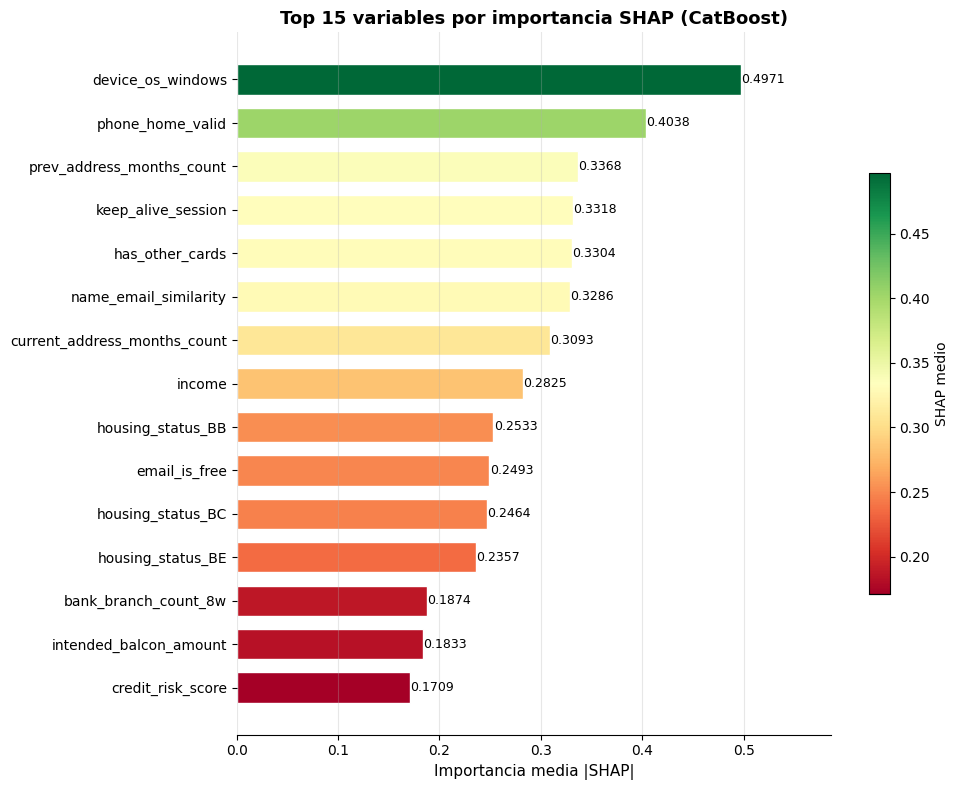

C:\Users\pausa\AppData\Local\Temp\ipykernel_4952\284976664.py:76: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



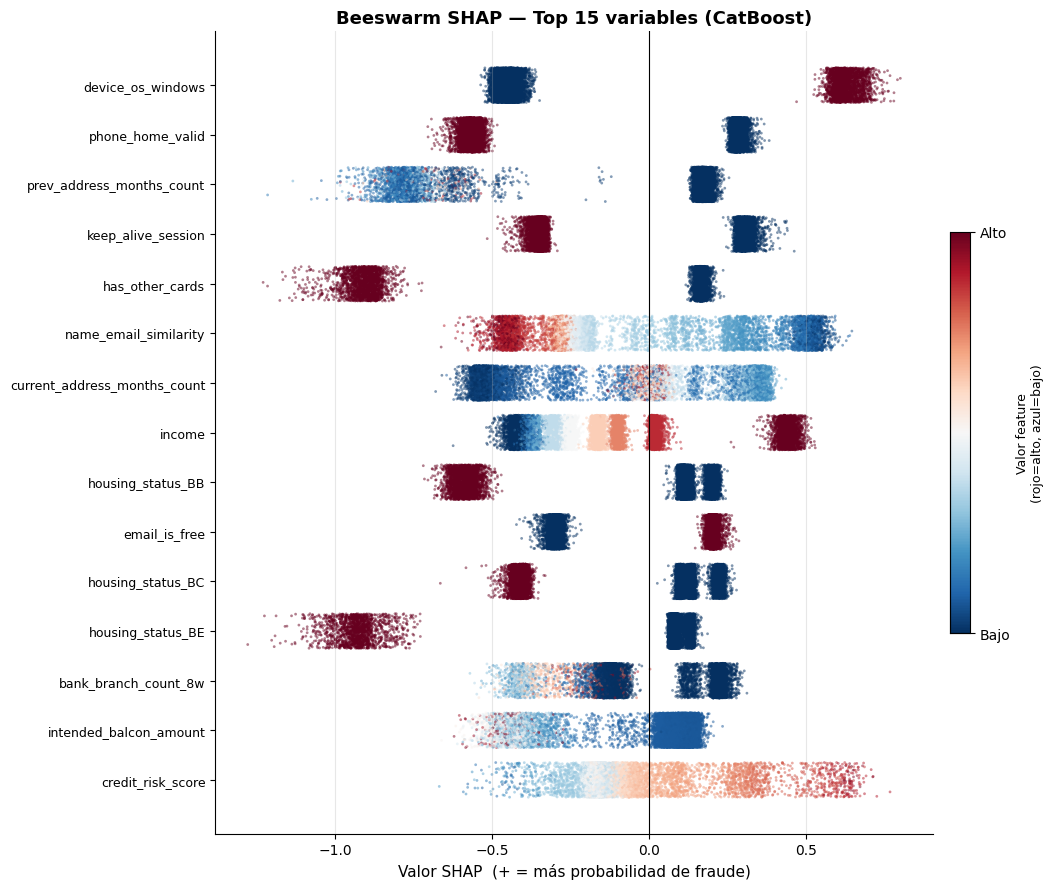

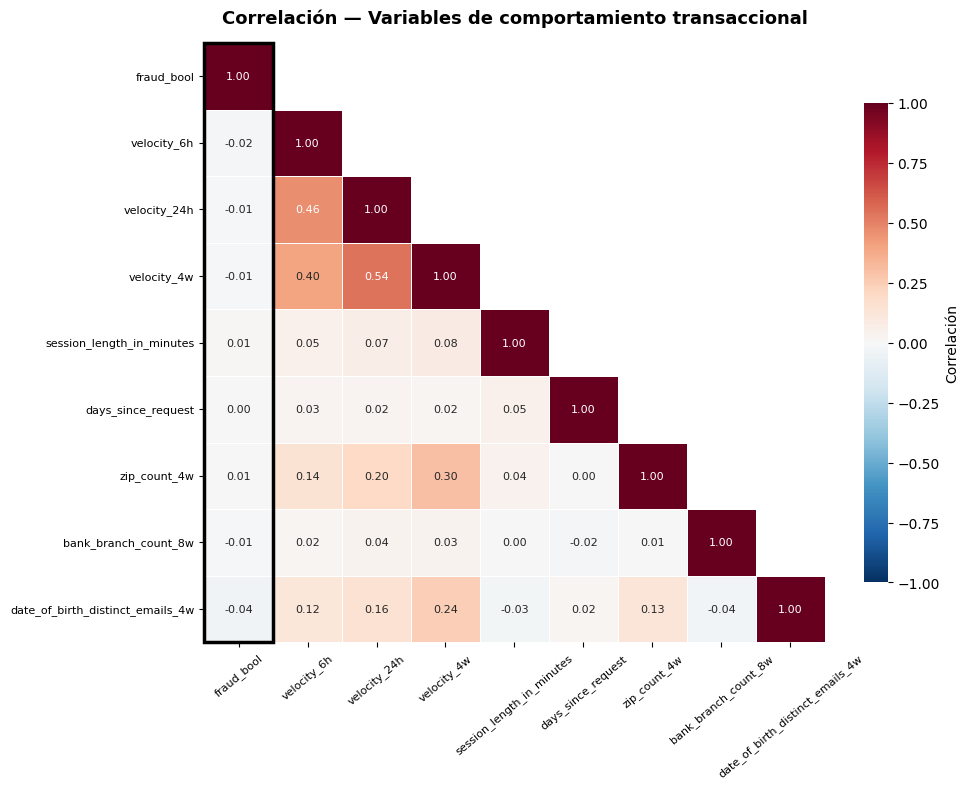

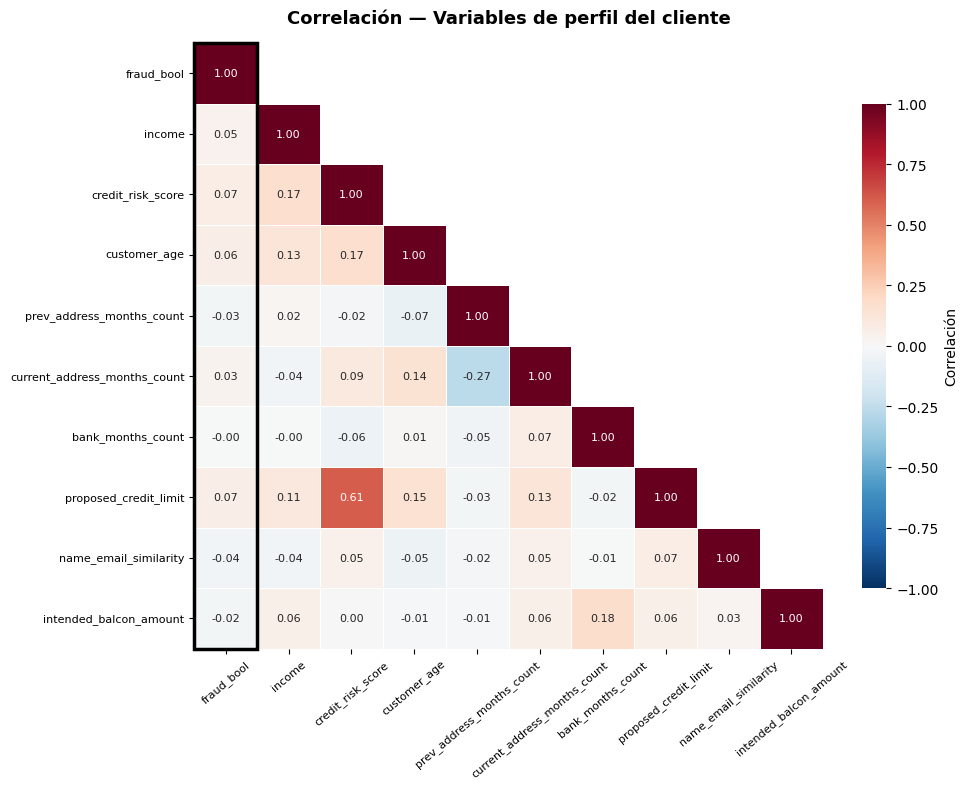

In [22]:
def importancia_y_correlacion_catboost(
    df: pd.DataFrame,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    target: str = "fraud_bool",
    top_n: int = 15,
    sample_size: int = 10_000,
    random_state: int = 42,
):
    # 1. Entrenar CatBoost
    print("Entrenando CatBoost...")
    X_train = X_train.drop(columns=[target], errors="ignore")
    scale = (y_train == 0).sum() / (y_train == 1).sum()

    model = cb.CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        class_weights={0: 1.0, 1: float(scale)},
        random_seed=random_state,
        verbose=0,
        eval_metric="AUC",
    )
    model.fit(X_train, y_train)

    # 2. Calcular SHAP
    print(f"Calculando SHAP values sobre muestra de {sample_size:,} filas...")
    X_sample = X_train.sample(n=sample_size, random_state=random_state)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    # 3. DataFrame de importancias
    importancias_df = pd.DataFrame({
        "Variable": X_train.columns,
        "SHAP_medio": np.abs(shap_values).mean(axis=0),
    }).sort_values("SHAP_medio", ascending=False).reset_index(drop=True)

    top_vars = importancias_df.head(top_n)["Variable"].tolist()
    top = importancias_df.head(top_n)

    # PLOT 1: Barras de importancia SHAP
    fig, ax = plt.subplots(figsize=(10, 8))

    norm = mcolors.Normalize(vmin=top["SHAP_medio"].min(), vmax=top["SHAP_medio"].max())
    cmap = cm.get_cmap("RdYlGn")
    colors = [cmap(norm(v)) for v in top["SHAP_medio"][::-1]]

    bars = ax.barh(top["Variable"][::-1].values, top["SHAP_medio"][::-1].values,
                   color=colors, edgecolor="white", height=0.7)

    for bar, val in zip(bars, top["SHAP_medio"][::-1].values):
        ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", ha="left", fontsize=9)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="SHAP medio", shrink=0.6)

    ax.set_xlabel("Importancia media |SHAP|", fontsize=11)
    ax.set_title(f"Top {top_n} variables por importancia SHAP (CatBoost)", fontsize=13, fontweight="bold")
    ax.set_xlim(0, top["SHAP_medio"].max() * 1.18)
    ax.grid(axis="x", alpha=0.3)
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.savefig("shap_importancias_barras.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    # PLOT 2: Beeswarm
    shap_df = pd.DataFrame(shap_values, columns=X_train.columns)[top_vars]
    feat_df = X_sample[top_vars].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(11, 9))
    cmap_bee = cm.get_cmap("RdBu_r")
    rng = np.random.default_rng(random_state)

    for i, var in enumerate(reversed(top_vars)):
        sv = shap_df[var].values
        fv = feat_df[var].values
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
        jitter = rng.uniform(-0.35, 0.35, size=len(sv))
        colors_bee = [cmap_bee(v) for v in fv_norm]
        ax.scatter(sv, np.full(len(sv), i) + jitter,
                   c=colors_bee, s=4, alpha=0.5, linewidths=0)

    ax.set_yticks(range(top_n))
    ax.set_yticklabels(list(reversed(top_vars)), fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Valor SHAP  (+ = más probabilidad de fraude)", fontsize=11)
    ax.set_title(f"Beeswarm SHAP — Top {top_n} variables (CatBoost)", fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

    sm_bee = cm.ScalarMappable(cmap=cmap_bee)
    sm_bee.set_array([])
    cbar = plt.colorbar(sm_bee, ax=ax, shrink=0.5, pad=0.02)
    cbar.set_label("Valor feature\n(rojo=alto, azul=bajo)", fontsize=9)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Bajo", "Alto"])

    sns.despine()
    plt.tight_layout()
    plt.savefig("shap_beeswarm.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    # PLOTS 3 y 4: Matrices de correlación
    grupos = [
        (
            ["fraud_bool", "velocity_6h", "velocity_24h", "velocity_4w",
             "session_length_in_minutes", "days_since_request",
             "zip_count_4w", "bank_branch_count_8w", "date_of_birth_distinct_emails_4w"],
            "Correlación — Variables de comportamiento transaccional",
            "correlacion_comportamiento_transaccional.png",
        ),
        (
            ["fraud_bool", "income", "credit_risk_score", "customer_age",
             "prev_address_months_count", "current_address_months_count",
             "bank_months_count", "proposed_credit_limit", "name_email_similarity",
             "intended_balcon_amount"],
            "Correlación — Variables de perfil del cliente",
            "correlacion_perfil_cliente.png",
        ),
    ]

    for grupo, titulo, nombre_archivo in grupos:
        cols = [c for c in grupo if c in df.columns]
        corr = df[cols].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 8}, ax=ax,
            cbar_kws={"label": "Correlación", "shrink": 0.8},
        )

        # Recuadro negro en la columna/fila de fraud_bool
        if "fraud_bool" in cols:
            idx = cols.index("fraud_bool")
            ax.add_patch(mpatches.Rectangle(
                (idx, 0), 1, len(cols),
                fill=False, edgecolor="black", lw=2.5, clip_on=False
            ))

        ax.set_title(titulo, fontsize=13, fontweight="bold", pad=14)
        ax.tick_params(axis="x", rotation=40, labelsize=8)
        ax.tick_params(axis="y", rotation=0, labelsize=8)
        plt.tight_layout()
        plt.savefig(nombre_archivo, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()

    return importancias_df, model


# Llamada
importancias_df, model = importancia_y_correlacion_catboost(
    df=df,
    X_train=X_train,
    y_train=y_train,
    target="fraud_bool",
    top_n=15,
    sample_size=10_000,
)

## 10. Reintegración del Target y Exportación del Dataset Final

Una vez completado el preprocesamiento (codificación OHE) y el análisis exploratorio, se reintegra la variable objetivo al dataset de features procesadas.

El fichero `base-tratada.csv` es el **dataset final** que se utilizará como entrada en el pipeline de modelado. Contiene:
- Todas las variables numéricas originales.
- Las columnas one-hot generadas a partir de las variables categóricas.
- La variable objetivo `fraud_bool`.


In [ ]:
df.to_csv("base-limpia.csv", index=False)


## 11. Distribución de Variables Numéricas por Clase

Se visualizan los histogramas de las principales variables numéricas separados por clase (fraude vs. no fraude).

**Decisión metodológica clave — normalización por clase**:  
Dado el fuerte desbalanceo (~98%/~2%), si no se normalizara por clase, las barras de "no fraude" dominarían visualmente ocultando el comportamiento de la clase fraudulenta. Por ello, se usa `histnorm="probability density"`, que normaliza cada clase de forma independiente y hace las distribuciones comparables.

**Interpretación**: si las distribuciones de ambas clases son claramente distintas para una variable, esa variable tiene **alto poder discriminativo** y será relevante para el modelo. Si se solapan completamente, la variable aporta poca información por sí sola.

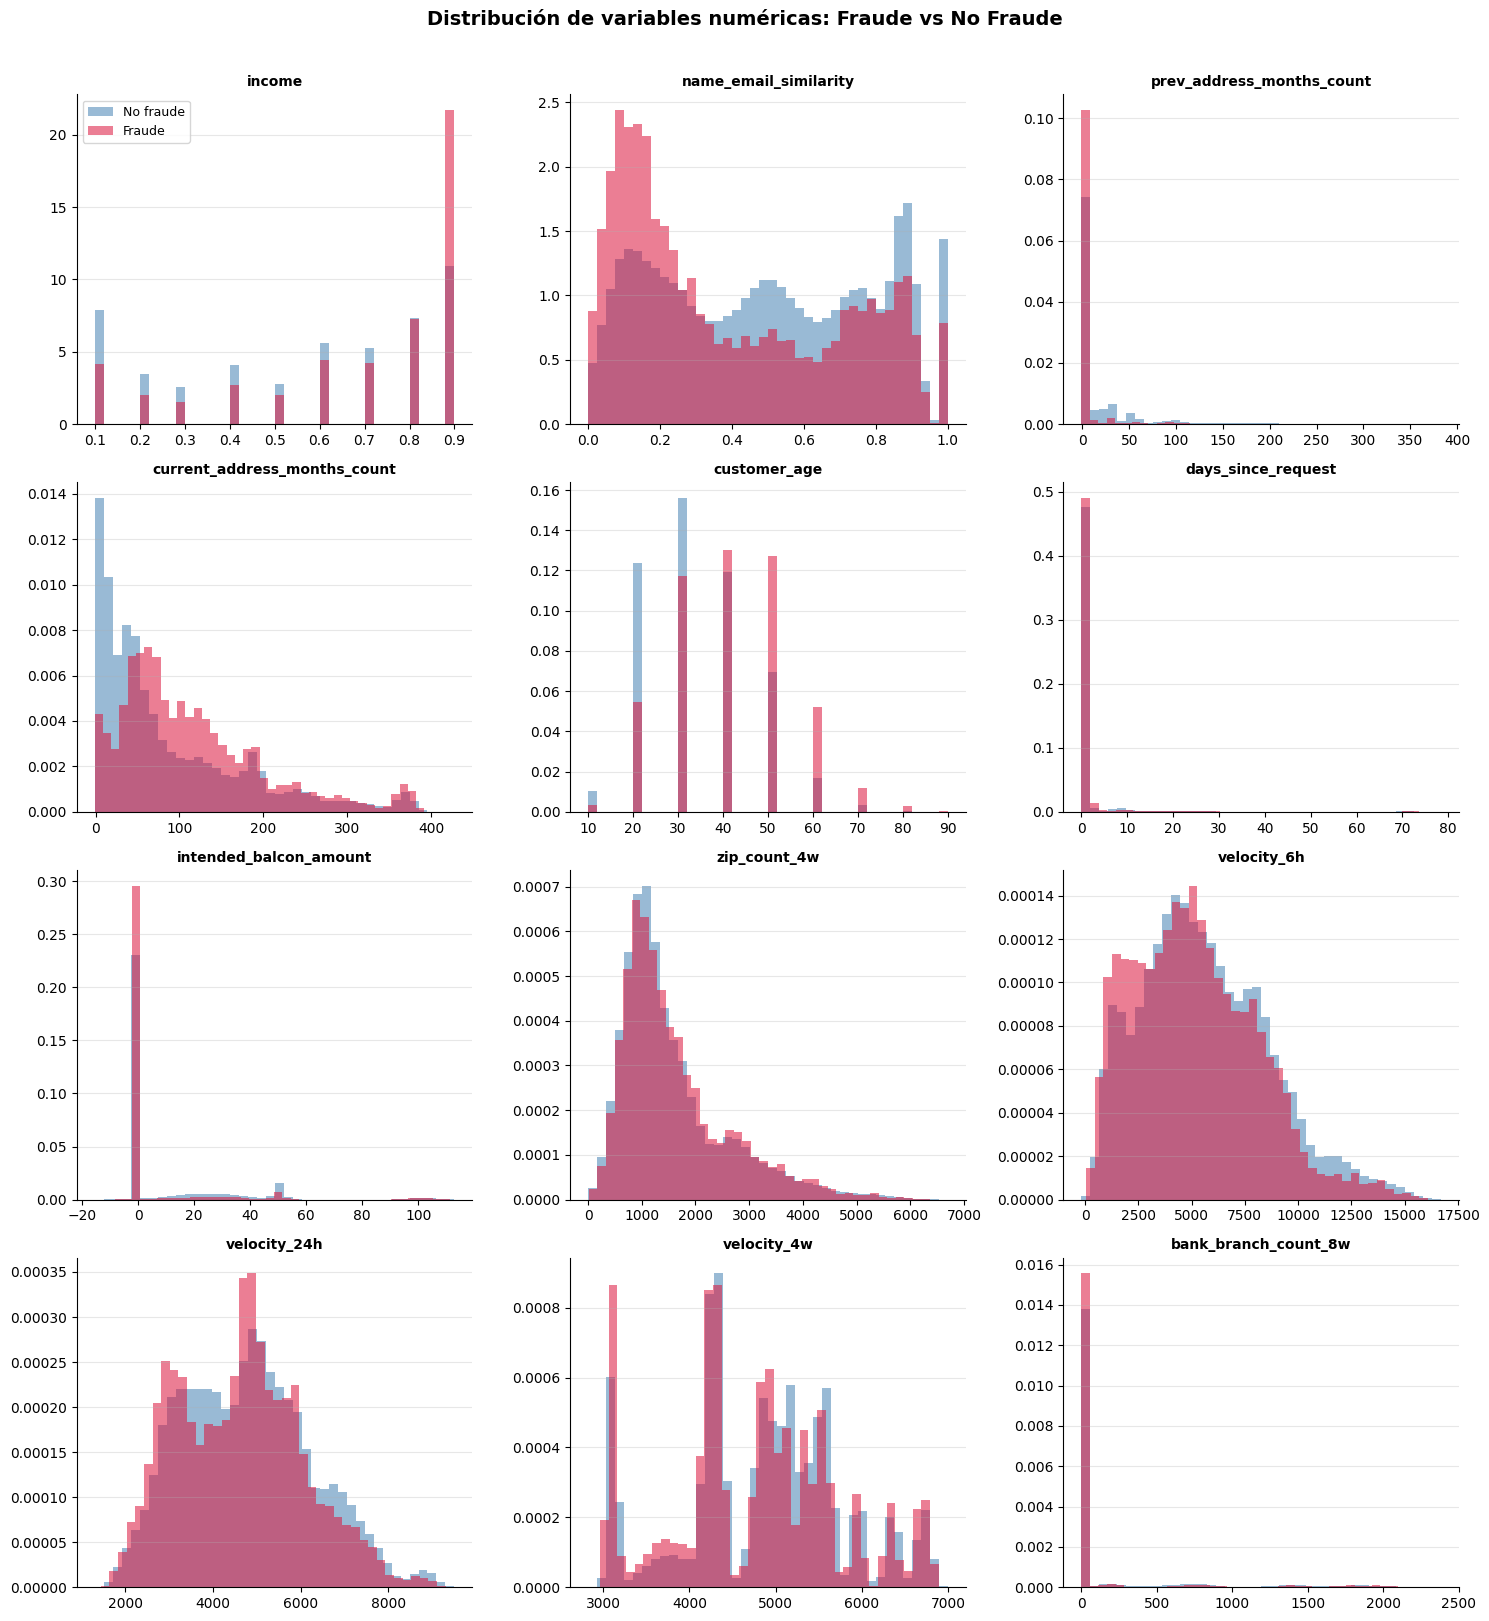

In [25]:
def distribuciones_por_clase(df, target, vars_numericas, top_n=12):
    cols = [c for c in vars_numericas if c in df.columns][:top_n]
    n_cols = 3
    n_rows = -(-len(cols) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        for clase, color, name in [
            (0, "steelblue", "No fraude"),
            (1, "crimson",   "Fraude"),
        ]:
            vals = df[df[target] == clase][col].dropna()
            ax.hist(vals, bins=40, density=True, alpha=0.55,
                    color=color, label=name, edgecolor="none")

        ax.set_title(col, fontsize=10, fontweight="bold")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.3)
        sns.despine(ax=ax)
        if i == 0:
            ax.legend(fontsize=9)

    # Ocultar ejes sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Distribución de variables numéricas: Fraude vs No Fraude",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("distribuciones_por_clase_var_numericas.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


df_original = pd.read_csv("Base.csv")

vars_numericas = [
    "income", "name_email_similarity", "prev_address_months_count",
    "current_address_months_count", "customer_age", "days_since_request",
    "intended_balcon_amount", "zip_count_4w", "velocity_6h", "velocity_24h",
    "velocity_4w", "bank_branch_count_8w", "credit_risk_score",
    "session_length_in_minutes", "proposed_credit_limit", "bank_months_count",
]

distribuciones_por_clase(df_original, target="fraud_bool", vars_numericas=vars_numericas, top_n=12)

## 12. Tasa de Fraude por Variable Categórica

Se analiza cómo varía la proporción de solicitudes fraudulentas en función de cada categoría de las variables categóricas originales (antes de la codificación OHE).

**Por qué es relevante para el informe**:
- Si la tasa de fraude difiere significativamente entre categorías, la variable es discriminativa y justifica su inclusión en el modelo.
- Si alguna categoría concentra tasas de fraude muy altas, puede ser señal de un **patrón de ataque** específico (p. ej., un tipo de pago particularmente explotado).
- Desde la perspectiva de *fairness*: si grupos identificados por `employment_status` o `housing_status` tienen tasas de fraude muy distintas, el modelo puede aprender a discriminar por estos atributos.

C:\Users\pausa\AppData\Local\Temp\ipykernel_4952\4115258081.py:17: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

C:\Users\pausa\AppData\Local\Temp\ipykernel_4952\4115258081.py:17: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

C:\Users\pausa\AppData\Local\Temp\ipykernel_4952\4115258081.py:17: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

C:\Users\pausa\AppData\Local\Temp\ipykernel_4952\4115258081.py:17: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matp

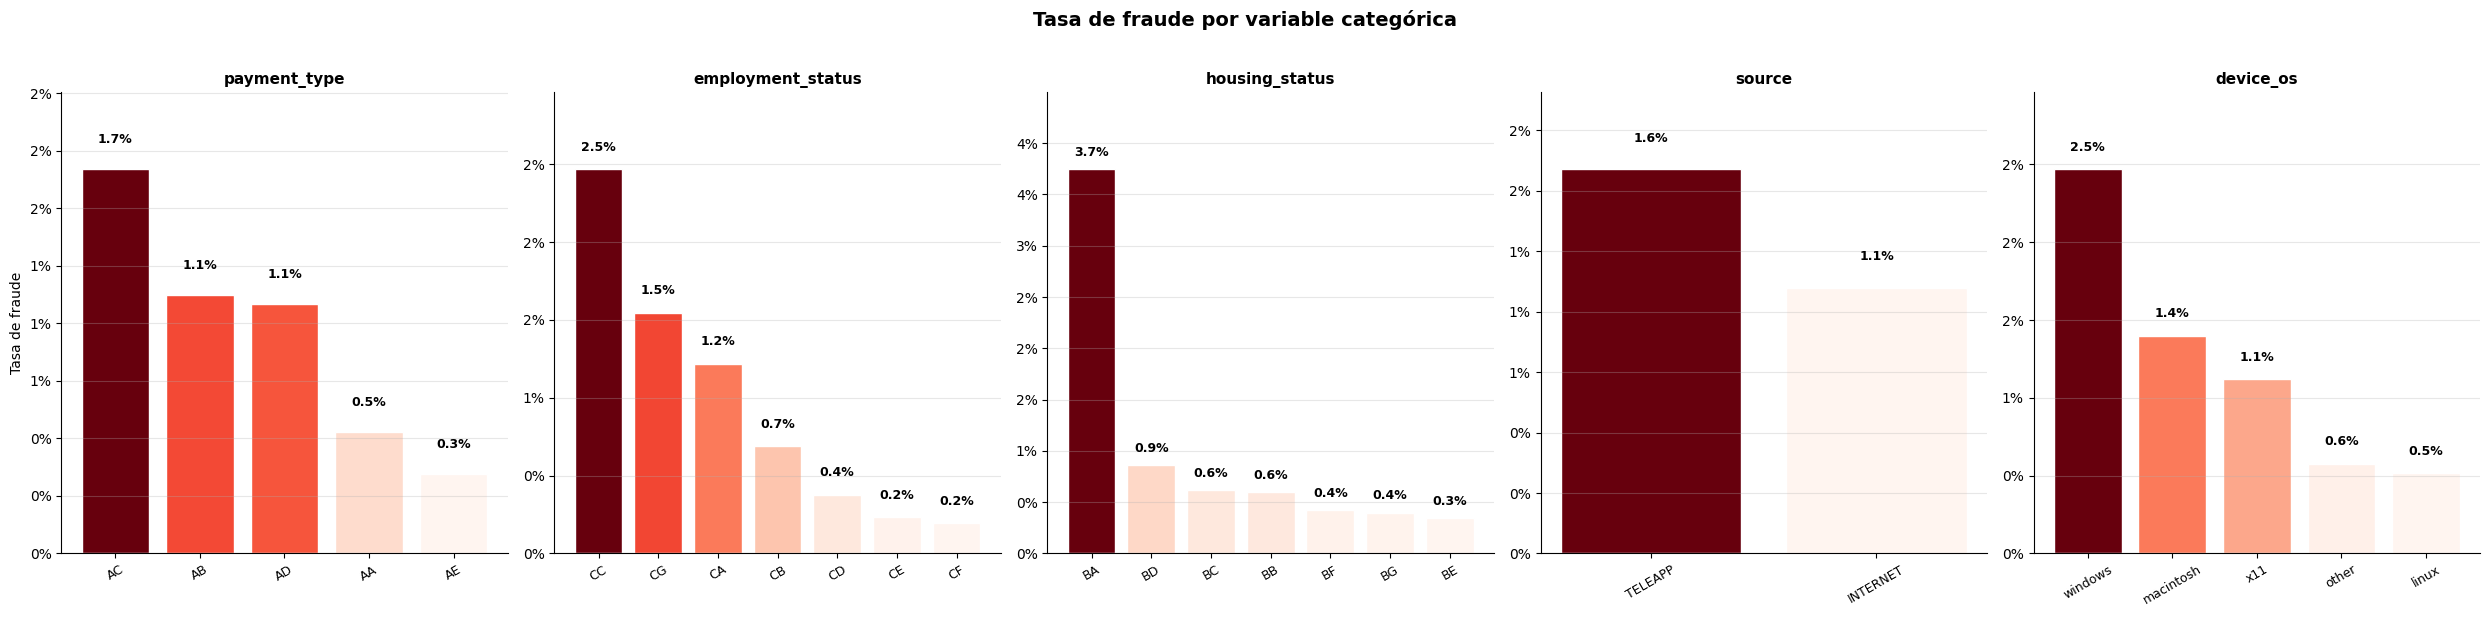

In [26]:
def fraude_por_categorica(df, target, cat_cols):
    n = len(cat_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, cat_cols):
        tasa = (
            df.groupby(col)[target]
            .mean()
            .sort_values(ascending=False)
            .reset_index()
        )
        tasa.columns = [col, "tasa_fraude"]

        norm = mcolors.Normalize(vmin=tasa["tasa_fraude"].min(), vmax=tasa["tasa_fraude"].max())
        cmap = cm.get_cmap("Reds")
        colors = [cmap(norm(v)) for v in tasa["tasa_fraude"]]

        bars = ax.bar(tasa[col].astype(str), tasa["tasa_fraude"],
                      color=colors, edgecolor="white")

        for bar, val in zip(bars, tasa["tasa_fraude"]):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.001,
                    f"{val*100:.1f}%",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

        ax.set_title(col, fontsize=11, fontweight="bold")
        ax.set_ylabel("Tasa de fraude" if ax == axes[0] else "")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax.tick_params(axis="x", rotation=30, labelsize=9)
        ax.set_ylim(0, tasa["tasa_fraude"].max() * 1.2)
        ax.grid(axis="y", alpha=0.3)
        sns.despine(ax=ax)

    fig.suptitle("Tasa de fraude por variable categórica",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("tasa_fraude_por_categorica.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


df_original = pd.read_csv("Base.csv")

cat_cols_originales = ["payment_type", "employment_status", "housing_status", "source", "device_os"]

fraude_por_categorica(df_original, target="fraud_bool", cat_cols=cat_cols_originales)